In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ['JAX_PLATFORMS'] = 'cpu'
import yaml
import sys
sys.path.append("..")

import os.path as osp
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm_notebook as tqdm
import torch.nn as nn
from torch_model import DiT
from torch_vae import AutoencoderKL

In [2]:
yaml_path = "../shortcutmodel_args.yaml"
device = "cuda"

with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)
    
dit_args = config['dit_args']
dit_args["dtype"] = torch.float32
vae_args = config['vae_args']
dit_weights = config.get('dit_weights', None)#.replace("shortcut-models", "..")
vae_weights = config.get('vae_weights', None)#.replace("shortcut-models", "..")

dit = DiT(**dit_args).to(device)
if dit_weights is not None:
    dit.load_state_dict(torch.load(dit_weights, map_location=device))
dit.eval()
vae = AutoencoderKL(**vae_args).to(device)
if vae_weights is not None:
    vae.load_state_dict(torch.load(vae_weights, map_location=device))
vae.eval()

AutoencoderKL(
  (encoder): Encoder(
    (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (down_blocks): ModuleList(
      (0): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0-1): 2 x ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-05, affine=True)
            (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm2): GroupNorm(32, 128, eps=1e-05, affine=True)
            (dropout): Dropout(p=0.0, inplace=False)
            (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
        )
        (downsampler): Downsample2D(
          (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
        )
      )
      (1): DownEncoderBlock2D(
        (resnets): ModuleList(
          (0): ResnetBlock2D(
            (norm1): GroupNorm(32, 128, eps=1e-05, affine=True)
            (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  

In [3]:
import numpy as np
from PIL import Image
import torch.fft as fft
import torch.nn.functional as F
import torchvision.transforms as transforms

def rescale_img(x):
    if isinstance(x, torch.Tensor):
        x = np.array(x.detach().cpu().numpy())
    shape = x.shape
    if len(shape) == 4 and shape[1] == 3:
        x = x.transpose(0, 2, 3, 1)
    elif len(shape) == 3 and shape[0] == 3:
        x = x.transpose(1, 2, 0)
    x = x * 0.5 + 0.5  # [-1,1] to [0,1]
    x = np.clip(x, 0, 1)
    x = (x * 255).astype(np.uint8)
    return x

def decode(x, rescale=True):
    if not isinstance(x, np.ndarray):
        x = x.detach().cpu().numpy()
    x_torch = torch.Tensor(x).to(device)
    x_decoded = vae.decode(x_torch)
    if not rescale:
        return x_decoded
    return rescale_img(x_decoded)

def encode(img, normalize=True):
    if normalize:
        img = img / 255.0
        img = (img - 0.5)/0.5
    img = img.float()
    with torch.no_grad():
        lat = vae.encode(img)
    return lat

def stochastic_encoding(img, ti, dts, noise=None):
    if noise is None:
        noise = torch.randn_like(img)
    t = ti/dts
    return t*img + (1-t)*noise

def step_to_end(z, v, t):
    return z + v*(1-t)

def gaussian_kernel(kernel_size=61, sigma=3.0, channels=3, device='cuda'):
    """
    Create a 2D Gaussian kernel for convolution
    """
    ax = torch.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1., device=device)
    xx, yy = torch.meshgrid(ax, ax, indexing='ij')
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.view(1, 1, kernel_size, kernel_size)
    kernel = kernel.repeat(channels, 1, 1, 1)  # multi-channel
    return kernel

def pad_and_shift_kernel(kernel, H, W):
    """
    Pads kernel to (H, W) centered, then ifftshifts it so that FFT interprets
    the kernel's center at the origin (0,0). This prevents circular shifts.
    """
    kh, kw = kernel.shape[-2:]

    pad_h = H - kh
    pad_w = W - kw

    # Centered padding
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    kernel_padded = F.pad(kernel, (pad_left, pad_right, pad_top, pad_bottom))

    # Move kernel center to (0,0) for FFT convolution
    kernel_shifted = fft.ifftshift(kernel_padded, dim=(-2, -1))

    return kernel_shifted


def solve_bp_fft_operator2(y, x0, kernel, rho=1.0, eps=1e-12):
    """
    Solves: x = (A^T A + rho I)^-1 (A^T y + rho x0)
    where A is convolution with kernel k.

    All FFT operations are done with correct kernel centering to avoid shifts.
    """

    B, C, H, W = y.shape

    # Prepare kernel
    if kernel.ndim == 2:  # (kh, kw)
        kernel = kernel.unsqueeze(0)  # -> (1, kh, kw)
    
    # Pad and shift kernel for FFT convolution
    kernel_reshaped = kernel.reshape(kernel.shape[0], 1, *kernel.shape[-2:])
    kernel_padded = pad_and_shift_kernel(kernel_reshaped, H, W)
    
    # Broadcast kernel if needed
    if kernel_padded.shape[0] == 1 and C > 1:
        kernel_padded = kernel_padded.repeat(C, 1, 1, 1)

    # Compute FFT of kernel (adjoint via conj)
    k_f = fft.rfft2(kernel_padded.reshape(C, H, W))   # (C, H, W/2+1)

    # Expand kernel to batch dimension
    k_f = k_f.unsqueeze(0).repeat(B, 1, 1, 1)         # (B,C,H,W/2+1)
    k_f = k_f.reshape(B * C, H, W // 2 + 1)

    # FFT of inputs
    y_f  = fft.rfft2(y.reshape(B * C, H, W))
    x0_f = fft.rfft2(x0.reshape(B * C, H, W))

    # Numerator: K* ⊙ Y + rho X0
    numerator = torch.conj(k_f) * y_f + rho * x0_f

    # Denominator: |K|^2 + rho
    denominator = (k_f.abs() ** 2) + rho + eps

    # Solve per-frequency
    x_f = numerator / denominator

    # Back to spatial domain
    x = fft.irfft2(x_f, s=(H, W))
    x = x.reshape(B, C, H, W)

    return x

def apply_convolution_operator(image, kernel):
    """
    Apply convolution operator A to an image using FFT: y = A * x
    
    Parameters:
    -----------
    image : torch.Tensor
        Input image of shape (B, C, H, W) or (C, H, W) or (H, W)
    kernel : torch.Tensor
        Convolution kernel of shape (kh, kw) or (C, kh, kw)
        
    Returns:
    --------
    torch.Tensor
        Convolved image, same shape as input
    """
    # Handle different input shapes
    original_shape = image.shape
    
    if image.ndim == 2:  # (H, W)
        image = image.unsqueeze(0).unsqueeze(0)  # -> (1, 1, H, W)
    elif image.ndim == 3:  # (C, H, W)
        image = image.unsqueeze(0)  # -> (1, C, H, W)
    
    B, C, H, W = image.shape
    
    # Prepare kernel
    if kernel.ndim == 2:  # (kh, kw)
        kernel = kernel.unsqueeze(0)  # -> (1, kh, kw)
    
    # Pad and shift kernel for FFT convolution
    kernel_reshaped = kernel.reshape(kernel.shape[0], 1, *kernel.shape[-2:])
    kernel_padded = pad_and_shift_kernel(kernel_reshaped, H, W)
    
    # Broadcast kernel if needed
    if kernel_padded.shape[0] == 1 and C > 1:
        kernel_padded = kernel_padded.repeat(C, 1, 1, 1)
    
    # Compute FFT of kernel
    k_f = fft.rfft2(kernel_padded.reshape(C, H, W))
    
    # Expand to batch dimension
    k_f = k_f.unsqueeze(0).repeat(B, 1, 1, 1)  # (B, C, H, W/2+1)
    k_f = k_f.reshape(B * C, H, W // 2 + 1)
    
    # FFT of image
    x_f = fft.rfft2(image.reshape(B * C, H, W))
    
    # Apply convolution in frequency domain
    y_f = k_f * x_f
    
    # Back to spatial domain
    y = fft.irfft2(y_f, s=(H, W))
    y = y.reshape(B, C, H, W)
    
    # Restore original shape
    if len(original_shape) == 2:
        y = y.squeeze(0).squeeze(0)
    elif len(original_shape) == 3:
        y = y.squeeze(0)
    
    return y


def read_image_to_tensor(image_path, normalize=True, device='cpu', return_np=False):
    """
    Read an image file and convert it to a PyTorch tensor.
    
    Args:
        image_path (str): Path to the image file
        normalize (bool): If True, normalize pixel values to [-1, 1]. Default: True
        device (str): Device to place the tensor on ('cpu' or 'cuda'). Default: 'cpu'
    
    Returns:
        torch.Tensor: Image tensor of shape (C, H, W) with values in [0, 1] if normalized,
                     or [0, 255] if not normalized
    
    Example:
        >>> img_tensor = read_image_to_tensor('path/to/image.jpg')
        >>> print(img_tensor.shape)  # (3, H, W)
    """
    # Read image using PIL
    image = Image.open(image_path).convert('RGB')
    
    # Convert to tensor
    if normalize:
        # Normalize to [-1, 1]
        transform = transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        img_tensor = transform(image)
    else:
        # Keep as [0, 255]
        img_array = np.array(image)
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).float()
    
    # Move to specified device
    img_tensor = img_tensor.to(device)
    
    if not return_np:
        return img_tensor[None, ...]
    return img_tensor[None, ...], np.asarray(image)

def to_numpy(t):
    if t.shape[0] == 1:
        t = t[0]
    if len(t.shape) == 3:
        t = t.permute(1, 2, 0)
    else:
        t = t.permute(0, 2, 3, 1)
    n = torch.clamp((t * 0.5 + 0.5) * 255, 0, 255)
    n = n.detach().cpu().numpy().astype("uint8")
    return n

In [4]:
def calc_t(ti, dts):
    t = ti / dts
    return t

def calc_v(x, t, denoise_timesteps, labels):
    batch_size = x.shape[0]

    t_vector = torch.full((batch_size,), t, dtype=torch.float32, device=device)
    dt_flow = int(np.log2(denoise_timesteps))
    dt_base = torch.ones(batch_size, dtype=torch.float32, device=device) * dt_flow
    # Classifier-free guidance
    labels_uncond = torch.ones_like(labels) * num_classes
    if cfg_scale == 1:
        v, *_ = dit(x, t_vector, dt_base, labels)
    elif cfg_scale == 0:
        v, *_ = dit(x, t_vector, dt_base, labels_uncond)
    else:
        v_pred_uncond, *_ = dit(x, t_vector, dt_base, labels_uncond)
        v_pred_label, *_ = dit(x, t_vector, dt_base, labels)
        v = v_pred_uncond + cfg_scale * (v_pred_label - v_pred_uncond)
    return v

In [5]:
sys.path.append("../../resample")
from ldm_inverse.measurements import get_noise, get_operator
from util.img_utils import Blurkernel
measure_config = {"operator" : {"blur_type": "gaussian",
                                    "kernel_size": 61,
                                    "std": 3.0},
                      "noise": {"name": "gaussian",
                                "sigma": 0.05}
                     }
device = "cuda:0"

kernel = Blurkernel(**measure_config["operator"],
                   device=device).get_kernel().to(device)


noiser = get_noise(**measure_config['noise'])

In [6]:
import os.path as osp
from glob import glob
from random import shuffle, seed
seed(1210)

images_dir = "/media/embedded/Datasets/Public/CelebAhq256/validation/"
images_paths = glob(osp.join(images_dir, "*.png"))
shuffle(images_paths)


In [7]:
num_classes = 1
cfg_scale = 0
model = dit
image_t, img = read_image_to_tensor(images_paths[0], device=device, return_np=True)
image_t_bl = apply_convolution_operator(image_t, kernel)
image_t_bl_n = noiser(image_t_bl)
image_t_bp = solve_bp_fft_operator2(image_t_bl_n, image_t_bl_n*0, kernel, 0.005)


image_t_latent = encode(image_t, False)
image_t_bl_latent = encode(image_t_bl, False)
image_t_bl_n_latent = encode(image_t_bl_n, False)
image_t_bp_latent = encode(image_t_bp, False)
labels = torch.randint(0, num_classes, (image_t_latent.shape[0],), device=device)

In [8]:
from tqdm.notebook import tqdm

0it [00:00, ?it/s]

301.4654235839844 451.0075378417969 -451.0075378417969 14.426517486572266
tensor([-78.8713, -38.0620, -13.8962,   2.0744,  14.4373,  26.3032,  40.6560,
         59.1715,  78.1944], device='cuda:0')
514.2625732421875 514.2625732421875 -362.91632080078125 -4.213000297546387
tensor([-4.9252e+01, -2.9835e+01, -1.6717e+01, -9.3497e+00, -4.2028e+00,
         1.9540e-02,  5.0760e+00,  1.3091e+01,  3.5258e+01], device='cuda:0')
2775.3125 3084.858154296875 -3084.858154296875 31.28046226501465
tensor([-303.2956, -162.6514,  -83.3382,  -22.2162,   31.3013,   77.4962,
         126.1622,  182.4765,  272.5174], device='cuda:0')
158.138427734375 158.138427734375 -106.08990478515625 -1.3360319137573242
tensor([-21.6971, -11.1358,  -6.1737,  -3.6249,  -1.3333,   0.8793,   3.5451,
          6.9184,  15.1954], device='cuda:0')
503.7631530761719 528.3450317382812 -528.3450317382812 5.128045082092285
tensor([-56.7700, -23.9925, -11.6143,  -2.7538,   5.1372,  14.0852,  24.3360,
         37.2508,  55.5670], 

317.6583557128906 317.6583557128906 -148.44761657714844 -2.8037800788879395
tensor([-27.5583, -14.5713, -10.3062,  -6.1184,  -2.8011,   3.0299,   8.8192,
         14.3394,  36.4509], device='cuda:0')
295.4144592285156 295.4144592285156 -283.5476379394531 2.3967912197113037
tensor([-45.1990, -11.3396,  -3.0878,  -0.0963,   2.3981,   5.3596,  11.0326,
         16.6021,  20.3408], device='cuda:0')
284.4482116699219 284.4482116699219 -142.84353637695312 -2.519803762435913
tensor([-23.9352, -12.2094,  -8.9933,  -5.1871,  -2.5165,   2.5782,   7.3159,
         11.5766,  31.6760], device='cuda:0')
320.6576843261719 371.73095703125 -371.73095703125 1.8402682542800903
tensor([-46.4835, -11.5239,  -2.3448,  -0.4015,   1.8405,   5.1221,  11.4313,
         17.1467,  21.3152], device='cuda:0')
339.561279296875 339.561279296875 -149.07131958007812 -1.7753820419311523
tensor([-23.5609, -14.3240,  -9.0053,  -4.3415,  -1.7749,   3.5819,   9.8178,
         13.9887,  31.3153], device='cuda:0')
203.6794433

97.65222930908203 97.65222930908203 -55.75634765625 -3.009366989135742
tensor([-12.4292,  -7.1355,  -5.1515,  -3.9472,  -3.0090,  -1.6844,   2.3760,
          7.4805,  10.7720], device='cuda:0')
126.38066864013672 126.38066864013672 -103.44571685791016 6.085808753967285
tensor([-32.4437, -19.8821,  -6.3780,   3.0551,   6.0884,   9.0726,  13.6973,
         17.8920,  24.4461], device='cuda:0')
189.8717803955078 189.8717803955078 -111.10892486572266 -0.05943341553211212
tensor([-10.8323,  -3.7971,  -2.3170,  -1.3051,  -0.0590,   1.2490,   2.6434,
          4.5055,   8.8721], device='cuda:0')
66.46150970458984 66.46150970458984 -58.05895233154297 -3.380095958709717
tensor([-7.8012, -6.1078, -4.8185, -4.0555, -3.3800, -2.3725, -0.0940,  5.6007,
        10.5278], device='cuda:0')
68.71029663085938 68.71029663085938 -54.24821853637695 5.559590816497803
tensor([-22.3388, -10.8622,  -2.0925,   3.2066,   5.5608,   7.7899,   9.8402,
         12.3014,  15.8898], device='cuda:0')
205.22874450683594

15.01051139831543 20.736499786376953 -20.736499786376953 0.05181333050131798
tensor([-3.2981, -0.9855, -0.4855, -0.2433,  0.0531,  0.3003,  0.6134,  1.4566,
         3.5796], device='cuda:0')


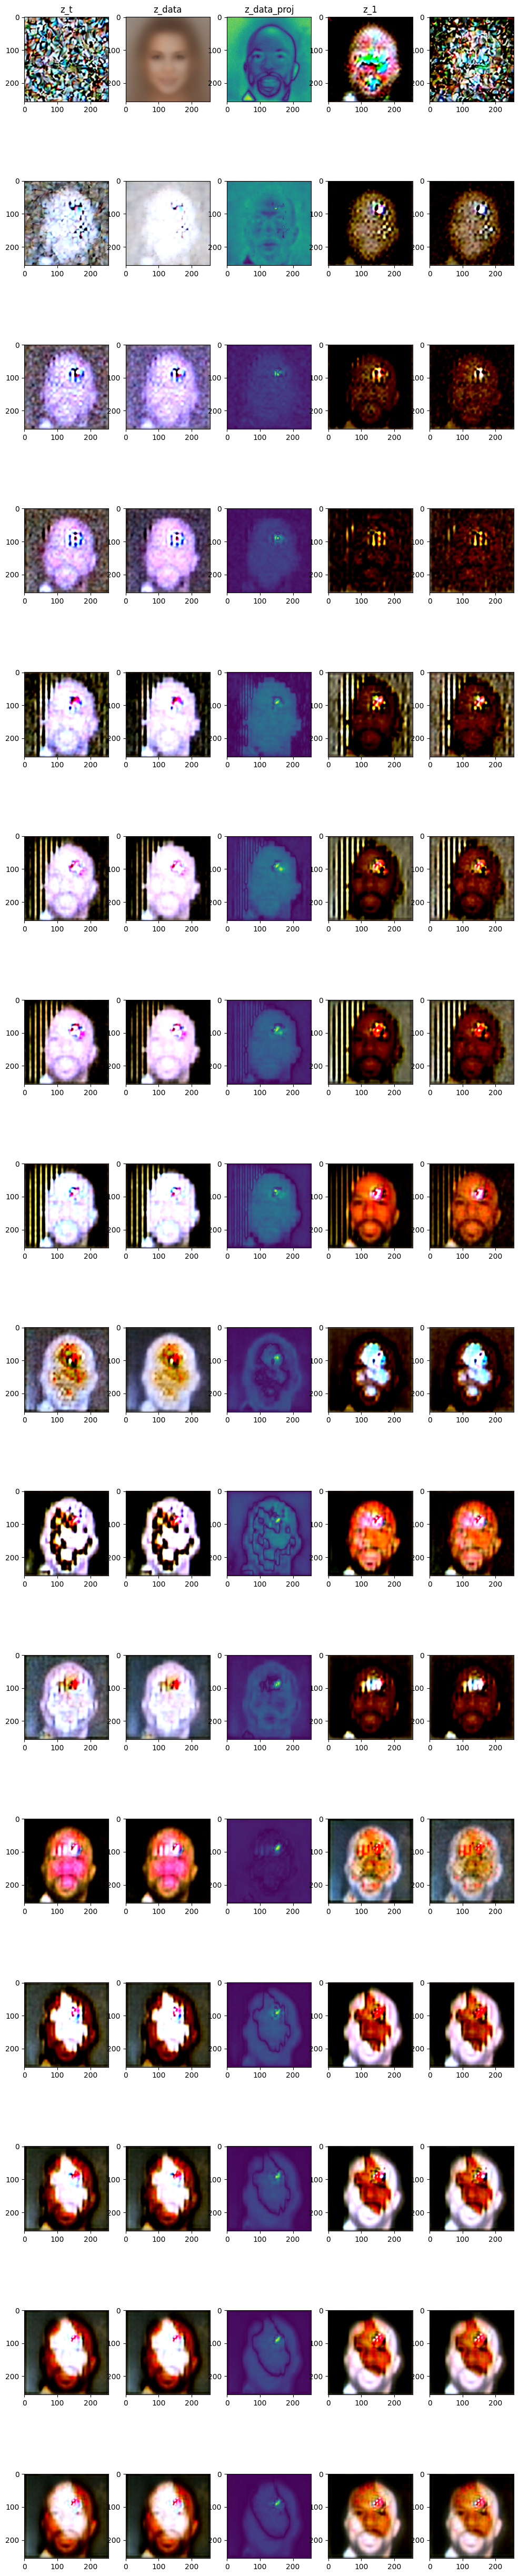

In [9]:
dts = 128
z_t = torch.randn_like(image_t_latent)
y = image_t_bl_n.clone()

draw_interval = 8
draw_steps = dts // draw_interval
fig, ax = plt.subplots(draw_steps, 5, figsize=(3*4, draw_steps*4))
for i, ti in tqdm(enumerate(range(dts))):
    lr = (1-ti/dts)**0.5
    draw = ti % draw_interval == 0
    draw_idx = ti // draw_interval
    
    if draw:
        if draw_idx == 0:
            for idx, tit in enumerate(["z_t", "z_data", "z_data_proj", "z_1"]):
                ax[0][idx].set_title(tit)
        ax[draw_idx][0].imshow(to_numpy(decode(z_t, False)))
        
    t = calc_t(ti, dts)
    v = calc_v(z_t, t, dts, labels)
    z_1 = z_t + (1-t)*v
    if draw:
        ax[draw_idx][1].imshow(to_numpy(decode(z_1, False)))
        
    z_1 = z_1.clone().detach().requires_grad_(True)

    
    x_1 = vae.decode(z_1)
    
    loss = (x_1 - y)**2
    if draw:
        loss_g = (2*(x_1-y))[0].abs().detach().cpu().numpy().max(0)
        loss_g_im = ((loss_g - loss_g.min())/(loss_g.max()-loss_g.min()) * 255).astype("uint8")
        ax[draw_idx][2].imshow(loss_g_im)
    loss.sum().backward()
    g = z_1.grad
    
    print(g.max().item(), g.abs().max().item(), g.min().item(), g.median().item())
    print(g.quantile(torch.arange(1, 10, device=device)/10))
    z_data = z_1 - lr*g
    if draw:
        ax[draw_idx][3].imshow(to_numpy(decode(z_data, False)))
    z_t = stochastic_encoding(z_data, ti+1, dts)
    if draw:
        ax[draw_idx][4].imshow(to_numpy(decode(z_t, False)))
    
    
    
    
    

0it [00:00, ?it/s]

-4.067549228668213 3.2487926483154297
-1.3125604391098022 1.1469700336456299
-4.037327289581299 3.2245595455169678
-1.3045034408569336 1.1264772415161133
-4.007370948791504 3.1995227336883545
-1.2937813997268677 1.2807308435440063
-3.977663993835449 3.1735928058624268
-1.2817742824554443 1.4516901969909668
-3.9481887817382812 3.1467766761779785
-1.2705110311508179 1.608577013015747
-3.918926954269409 3.119124412536621
-1.2615394592285156 1.7299944162368774
-3.889859914779663 3.0907092094421387
-1.255634069442749 1.8242980241775513
-3.8609707355499268 3.061614990234375
-1.2530032396316528 1.8981540203094482
-3.8322489261627197 3.0319254398345947
-1.2535626888275146 1.9563608169555664
-3.8036954402923584 3.002915143966675
-1.257050633430481 2.0022079944610596
-3.775322675704956 2.9903717041015625
-1.2630326747894287 2.037978410720825
-3.747150182723999 2.978234052658081
-1.2709001302719116 2.065399646759033
-3.719197988510132 2.9664456844329834
-1.2799456119537354 2.085927963256836
-3.69

-2.805655002593994 2.7426016330718994
-2.514164686203003 2.519261360168457
-2.808974266052246 2.746859312057495
-2.5338187217712402 2.5344345569610596
-2.8119418621063232 2.7508206367492676
-2.553684711456299 2.5498907566070557
-2.8145675659179688 2.7544848918914795
-2.5737526416778564 2.56562876701355
-2.816866159439087 2.75784969329834
-2.5940120220184326 2.5816471576690674
-2.818857431411743 2.7609164714813232
-2.614452600479126 2.5979442596435547
-2.8205673694610596 2.763692855834961
-2.635064125061035 2.6145191192626953
-2.822026491165161 2.7661945819854736
-2.6558377742767334 2.6313719749450684
-2.823272705078125 2.768441677093506
-2.676767110824585 2.648505687713623
-2.8243491649627686 2.7704577445983887
-2.697850227355957 2.6659274101257324
-2.8253021240234375 2.7722649574279785
-2.7190921306610107 2.683650255203247
-2.8261640071868896 2.773879051208496
-2.740506410598755 2.7016959190368652
-2.82692813873291 2.775296926498413
-2.7621119022369385 2.7200961112976074
-2.8275499343

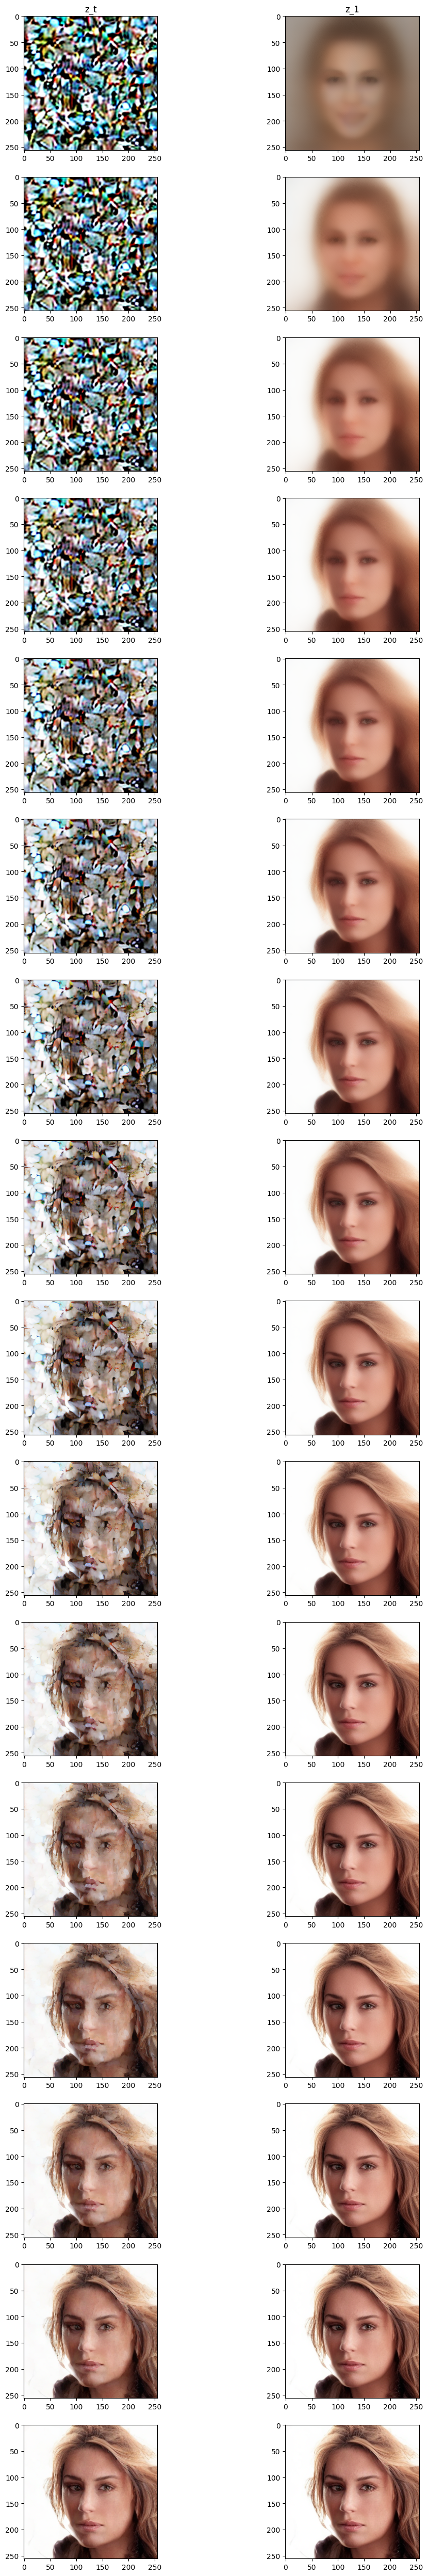

In [14]:
dts = 128
z_t = torch.randn_like(image_t_latent)
y = image_t_bl_n.clone()

draw_interval = 8
draw_steps = dts // draw_interval
fig, ax = plt.subplots(draw_steps, 2, figsize=(3*4, draw_steps*4))

for i, ti in tqdm(enumerate(range(dts))):
    print(z_t.min().item(), z_t.max().item())
    draw = ti % draw_interval == 0
    draw_idx = ti // draw_interval
    if draw:
        if draw_idx == 0:
            for idx, tit in enumerate(["z_t", "z_1"]):
                ax[0][idx].set_title(tit)
        ax[draw_idx][0].imshow(to_numpy(decode(z_t, False)))
        
    t = calc_t(ti, dts)
    v = calc_v(z_t, t, dts, labels)
    z_1 = z_t + (1-t)*v
    print(z_1.min().item(), z_1.max().item())
    z_t = z_t + 1/dts*v
    if draw:
        ax[draw_idx][1].imshow(to_numpy(decode(z_1, False)))
            
    
    
    
    

In [11]:
image_t_bl_n_latent.min()

tensor(-4.1688, device='cuda:0')

In [12]:
print(x_t.requires_grad)
print(x_t.grad_fn)

NameError: name 'x_t' is not defined

In [ ]:
print("is_leaf:", z_t.is_leaf)

In [ ]:
torch.quantile?